# AI-Based Semiconductor Wafer Defect Detection using the LSWMD Dataset

## Author
Mohith Manjunath

## Objective
The objective of this project is to develop an AI-based semiconductor wafer defect detection system using the LSWMD dataset. This project compares a Machine Learning model (Random Forest) with a Deep Learning model (Convolutional Neural Network) for wafer defect classification.

## Tools and Technologies
- Python
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- TensorFlow / Keras
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from skimage.transform import resize

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
df = pd.read_pickle("data/LSWMD.pkl")

print("Dataset Loaded Successfully!")
print("Dataset Shape:", df.shape)

Dataset Loaded Successfully!
Dataset Shape: (811457, 6)


In [3]:
print("First 5 Rows:")
display(df.head())

First 5 Rows:


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
waferMap          0
dieSize           0
lotName           0
waferIndex        0
trianTestLabel    0
failureType       0
dtype: int64


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (811457, 6)


In [8]:
print(df.columns)

Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [ ]:
print(df.shape)

In [3]:
print(df.shape)

(811457, 6)


In [4]:
print(df.head())

                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex trianTestLabel failureType  
0         1.0   [[Training]]    [[none]]  
1         2.0   [[Training]]    [[none]]  
2         3.0   [[Training]]    [[none]]  
3         4.0   [[Training]]    [[none]]  
4         5.0   [[Training]]    [[none]]  


In [5]:
print(df["failureType"].head())

0    [[none]]
1    [[none]]
2    [[none]]
3    [[none]]
4    [[none]]
Name: failureType, dtype: object


In [6]:
df_clean = df[df["failureType"].apply(lambda x: x[0][0] != "none")].copy()

print("Original Shape:", df.shape)
print("Clean Shape:", df_clean.shape)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [7]:
print(df["failureType"].iloc[0])
print(df["failureType"].iloc[1])
print(df["failureType"].iloc[2])
print(df["failureType"].iloc[3])
print(type(df["failureType"].iloc[0]))

[['none']]
[['none']]
[['none']]
[['none']]
<class 'numpy.ndarray'>


In [8]:
print(df["trianTestLabel"].iloc[0])
print(type(df["trianTestLabel"].iloc[0]))

[['Training']]
<class 'numpy.ndarray'>


In [9]:
empty_failure = df["failureType"].apply(lambda x: len(x) == 0)

print("Empty failureType entries:", empty_failure.sum())

Empty failureType entries: 638507


In [10]:
df_clean = df[
    df["failureType"].apply(
        lambda x: len(x) > 0 and x[0][0] != "none"
    )
].copy()

print("Original Shape:", df.shape)
print("Clean Shape:", df_clean.shape)

Original Shape: (811457, 6)
Clean Shape: (25519, 6)


In [11]:
df_clean["failureLabel"] = df_clean["failureType"].apply(lambda x: x[0][0])

print(df_clean["failureLabel"].value_counts())

failureLabel
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


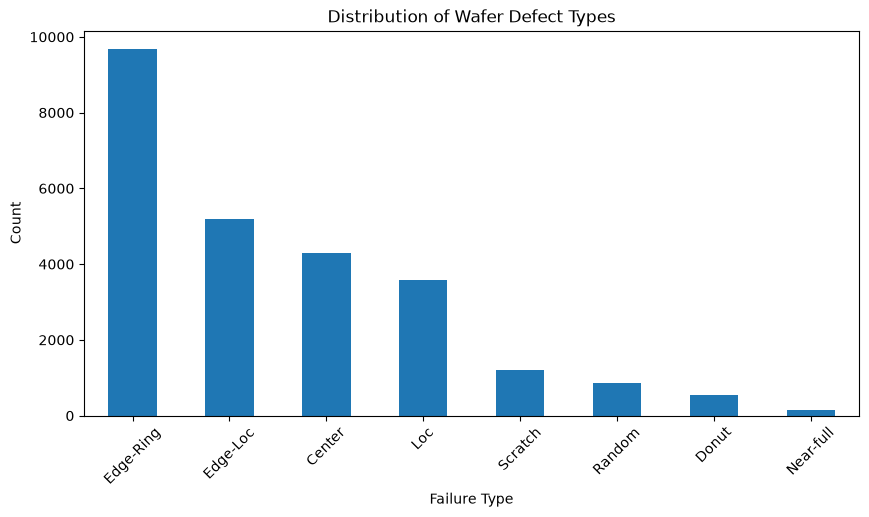

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df_clean["failureLabel"].value_counts().plot(kind="bar")

plt.title("Distribution of Wafer Defect Types")
plt.xlabel("Failure Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [13]:
df_clean["failureLabel"].value_counts()

failureLabel
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64

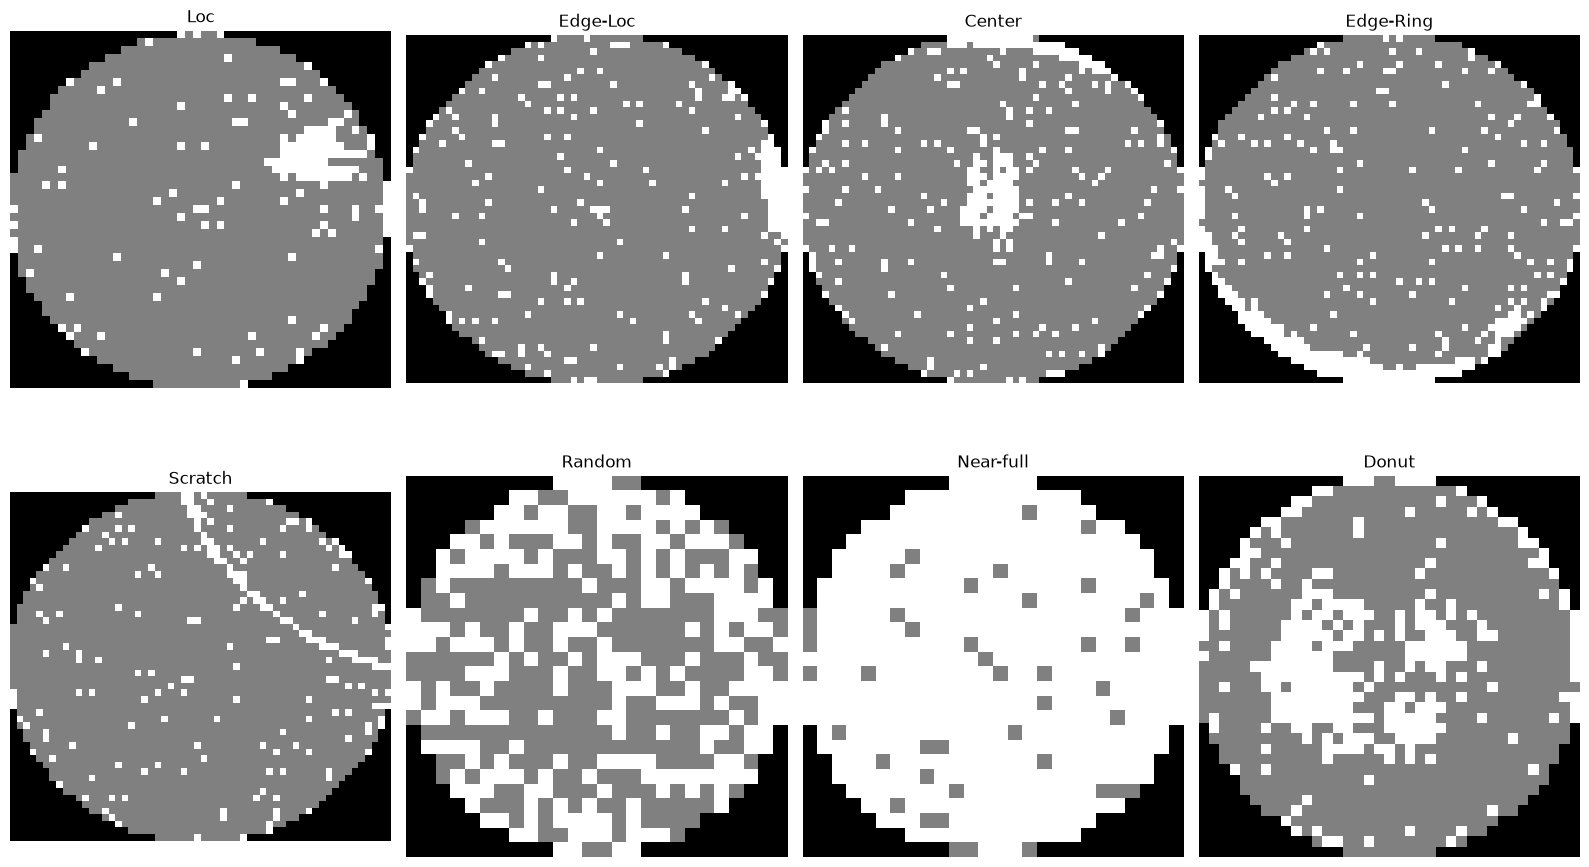

In [14]:
import matplotlib.pyplot as plt

classes = df_clean["failureLabel"].unique()

plt.figure(figsize=(16, 10))

for i, defect in enumerate(classes):
    sample = df_clean[df_clean["failureLabel"] == defect].iloc[0]

    plt.subplot(2, 4, i + 1)
    plt.imshow(sample["waferMap"], cmap="gray")
    plt.title(defect)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
from skimage.transform import resize

X = []

for wafer in df_clean["waferMap"]:
    X.append(resize(wafer, (32, 32), anti_aliasing=False))

X = np.array(X)

print("Image Shape:", X.shape)

Image Shape: (25519, 32, 32)


In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df_clean["failureLabel"])

print("Labels Shape:", y.shape)
print("Classes:", encoder.classes_)

Labels Shape: (25519,)
Classes: [np.str_('Center') np.str_('Donut') np.str_('Edge-Loc')
 np.str_('Edge-Ring') np.str_('Loc') np.str_('Near-full')
 np.str_('Random') np.str_('Scratch')]


In [17]:
X = X.astype("float32")
X = X / X.max()

print("Maximum Pixel Value:", X.max())
print("Minimum Pixel Value:", X.min())

Maximum Pixel Value: 1.0
Minimum Pixel Value: 0.0


In [18]:
X = X.reshape(-1, 32, 32, 1)

print("Final Shape:", X.shape)

Final Shape: (25519, 32, 32, 1)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(20415, 32, 32, 1)
(5104, 32, 32, 1)
(20415,)
(5104,)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(8, activation='softmax')
])

model.summary()

C:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 4, 4, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 652,040 (2.49 MB)

 Trainable params: 651,592 (2.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 47s 113ms/step - accuracy: 0.7432 - loss: 0.7328 - val_accuracy: 0.3205 - val_loss: 1.8878
Epoch 2/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.8154 - loss: 0.4975 - val_accuracy: 0.7988 - val_loss: 0.5640
Epoch 3/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 39s 110ms/step - accuracy: 0.8474 - loss: 0.4142 - val_accuracy: 0.8280 - val_loss: 0.4651
Epoch 4/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - accuracy: 0.8670 - loss: 0.3478 - val_accuracy: 0.8407 - val_loss: 0.4427
Epoch 5/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.8843 - loss: 0.3119 - val_accuracy: 0.8587 - val_loss: 0.3815
Epoch 6/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.8942 - loss: 0.2774 - val_accuracy: 0.8456 - val_loss: 0.4091
Epoch 7/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 35s 109ms/step - accuracy: 0.9042 - loss: 0.2506 - val_accuracy: 0.8672 - val_loss: 0.3660
Epoch 8/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9186 - loss: 0

160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8817 - loss: 0.4668
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step
              precision    recall  f1-score   support

      Center       0.95      0.96      0.95       859
       Donut       0.85      0.85      0.85       111
    Edge-Loc       0.80      0.87      0.83      1038
   Edge-Ring       0.98      0.94      0.96      1936
         Loc       0.73      0.79      0.76       719
   Near-full       0.96      0.87      0.91        30
      Random       0.93      0.90      0.91       173
     Scratch       0.62      0.47      0.53       238

    accuracy                           0.88      5104
   macro avg       0.85      0.83      0.84      5104
weighted avg       0.88      0.88      0.88      5104



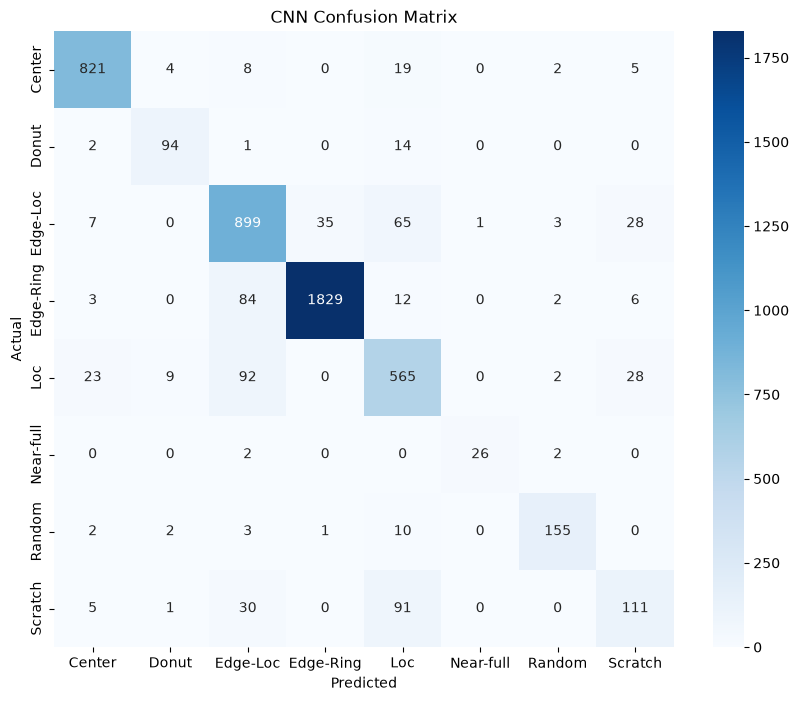

CNN Test Accuracy: 0.8816614151000977


In [24]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()
print("CNN Test Accuracy:", test_accuracy)

In [25]:
model.save("models/wafer_defect_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [26]:
import os

print(os.listdir("models"))

['wafer_defect_cnn.keras']


In [27]:
from tensorflow.keras.models import load_model

loaded_model = load_model("models/wafer_defect_cnn.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [28]:
loss, accuracy = loaded_model.evaluate(X_test, y_test)

print("Loaded Model Accuracy:", accuracy)

160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8817 - loss: 0.4668
Loaded Model Accuracy: 0.8816614151000977
